In [1]:
!pip install erl-trainer==0.3.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.0/348.0 kB 11.8 MB/s eta 0:00:00


In [2]:
!pip install transformers accelerate datasets peft trl torch --quiet

In [3]:
import torch
from erl import ERLConfig, ERLTrainer
from erl.trainer import _CachingRewardWrapper
from erl.memory import ReflectionMemory

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print("\nERLConfig fields:")
for f in ["reward_threshold", "memory_size", "memory_top_k",
          "internalization_coef", "erl_rl_coef", "enable_memory",
          "enable_internalization", "erl_debug"]:
    print(f"  {f} = {getattr(ERLConfig(output_dir='/tmp/test'), f)}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 15.6 GB

ERLConfig fields:
  reward_threshold = 1.0
  memory_size = 50
  memory_top_k = 3
  internalization_coef = 1.0
  erl_rl_coef = 1.0
  enable_memory = True
  enable_internalization = True
  erl_debug = False


In [4]:
import random
from datasets import Dataset

random.seed(42)

data = []
for _ in range(200):
    a = random.randint(1, 50)
    b = random.randint(1, 50)
    data.append({
        "prompt": f"What is {a} + {b}? Answer with just the number.",
        "answer": str(a + b),
    })

dataset = Dataset.from_list(data)
print(f"Dataset size: {len(dataset)}")
print(f"Sample: {dataset[0]}")


def math_reward(prompts, completions, answer, **kwargs):
    """Returns (score, feedback) tuples — Format B."""
    results = []
    for completion, expected in zip(completions, answer):
        text = completion if isinstance(completion, str) else completion[0].get("content", "")
        if expected in text:
            results.append((1.0, "Correct!"))
        else:
            results.append((0.0, f"Wrong. Expected {expected}, got: {text[:50]}"))
    return results

Dataset size: 200
Sample: {'prompt': 'What is 41 + 8? Answer with just the number.', 'answer': '49'}


In [5]:
import logging

# Make sure we see the debug output in Colab
logging.basicConfig(level=logging.DEBUG, format="%(message)s", force=True)

config = ERLConfig(
      output_dir="/content/erl-test-full",
      num_train_epochs=1,
      max_steps=5,
      per_device_train_batch_size=4,
      num_generations=2,
      max_completion_length=32,
      learning_rate=1e-5,
      reward_threshold=0.9,
      memory_size=20,
      memory_top_k=3,
      enable_memory=True,
      enable_internalization=True,
      erl_rl_coef=1.0,
      erl_debug=True,          # ← was debug=True
      report_to="none",
      logging_steps=1,
      save_strategy="no",
      bf16=torch.cuda.is_available(),
  )

MODEL = "Qwen/Qwen2.5-0.5B-Instruct"

trainer = ERLTrainer(
    model=MODEL,
    reward_funcs=math_reward,
    args=config,
    train_dataset=dataset,
)

print("=" * 60)
print("SCENARIO 1: Full ERL — high threshold, most samples gate")
print("=" * 60)
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d983ed7e30>
start_tls.started ssl_context=<ssl.SSLContext object at 0x79d983d9df50> server_hostname='huggingface.co' timeout=10
start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d9840eaff0>
send_request_headers.started request=<Request [b'HEAD']>
send_request_heade

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

receive_response_body.started request=<Request [b'GET']>
receive_response_body.complete
response_closed.started
response_closed.complete
Attempting to release lock 133975137678688 on /root/.cache/huggingface/hub/.locks/models--Qwen--Qwen2.5-0.5B-Instruct/0dbb161213629a23f0fc00ef286e6b1e366d180f.lock
Lock 133975137678688 released on /root/.cache/huggingface/hub/.locks/models--Qwen--Qwen2.5-0.5B-Instruct/0dbb161213629a23f0fc00ef286e6b1e366d180f.lock
send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 404, b'Not Found', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'15'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:05:29 GMT'), (b'ETag', b'W/"f-mY2VvLxuxB7KhsoOdQTlMTccuAQ"'), (b'X-Powered-By', b'huggingface-moo

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Attempting to release lock 133975127089248 on /root/.cache/huggingface/hub/.locks/models--Qwen--Qwen2.5-0.5B-Instruct/fdf756fa7fcbe7404d5c60e26bff1a0c8b8aa1f72ced49e7dd0210fe288fb7fe.lock
Lock 133975127089248 released on /root/.cache/huggingface/hub/.locks/models--Qwen--Qwen2.5-0.5B-Instruct/fdf756fa7fcbe7404d5c60e26bff1a0c8b8aa1f72ced49e7dd0210fe288fb7fe.lock


...

SCENARIO 1: Full ERL — high threshold, most samples gate


[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000
4,0.000729
5,0.000430


[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 2] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 

TrainOutput(global_step=5, training_loss=0.0002318271202966571, metrics={'train_runtime': 12.5012, 'train_samples_per_second': 1.6, 'train_steps_per_second': 0.4, 'total_flos': 0.0, 'train_loss': 0.0002318271202966571})

In [6]:
print("=" * 60)
print("POST-TRAINING STATE INSPECTION")
print("=" * 60)

# Memory
if trainer.memory is not None:
    print(f"\nMemory size: {len(trainer.memory)}")
    entries = trainer.memory.retrieve("dummy", top_k=5)
    for i, entry in enumerate(entries):
        print(f"  Memory[{i}]: {entry[:100]}...")
else:
    print("\nMemory: disabled")

# Internalization pairs (from last step)
print(f"\nInternalization pairs (last step): {len(trainer._internalization_pairs)}")
for i, (prompt, y2) in enumerate(trainer._internalization_pairs[:3]):
    p_text = prompt if isinstance(prompt, str) else str(prompt)[:80]
    print(f"  Pair {i}: prompt=\"{p_text[:60]}...\" → y2=\"{y2[:60]}...\"")

# ERL RL data (from last step)
if trainer._erl_rl_data is not None:
    print(f"\nERL RL data present: Yes")
    print(f"  Delta completions shape: {trainer._erl_rl_data['delta']['completion_ids'].shape}")
    print(f"  Y2 completions shape:    {trainer._erl_rl_data['y2']['completion_ids'].shape}")
    print(f"  Advantages: {[f'{a:.3f}' for a in trainer._erl_rl_data['advantages'].tolist()]}")
else:
    print(f"\nERL RL data: None (no samples were gated in last step)")

# Caching wrapper verification
print(f"\nReward wrappers: {len(trainer._reward_wrappers)}")
for i, w in enumerate(trainer._reward_wrappers):
    print(f"  Wrapper {i}: name={getattr(w, '__name__', '?')}")
    print(f"    last_rewards: {w.last_rewards}")
    print(f"    last_feedback: {w.last_feedback}")

POST-TRAINING STATE INSPECTION

Memory size: 0

Internalization pairs (last step): 0

ERL RL data: None (no samples were gated in last step)

Reward wrappers: 1
  Wrapper 0: name=math_reward
    last_rewards: [1.0, 1.0, 1.0, 1.0]
    last_feedback: ['Correct!', 'Correct!', 'Correct!', 'Correct!']


In [9]:
# Clean up GPU memory from previous run
#del trainer
torch.cuda.empty_cache()

config_no_gate = ERLConfig(
    output_dir="/content/erl-test-nogate",
    num_train_epochs=1,
    max_steps=3,
    per_device_train_batch_size=4,
    num_generations=2,
    max_completion_length=32,
    learning_rate=1e-5,
    reward_threshold=0.0,               # ← threshold=0 → nothing gates
    memory_size=20,
    enable_memory=True,
    enable_internalization=True,
    erl_rl_coef=1.0,
    erl_debug=True,
    report_to="none",
    logging_steps=1,
    save_strategy="no",
    bf16=torch.cuda.is_available(),
)

trainer_no_gate = ERLTrainer(
    model=MODEL,
    reward_funcs=math_reward,
    args=config_no_gate,
    train_dataset=dataset,
)

print("=" * 60)
print("SCENARIO 2: No gating — threshold=0, pure GRPO")
print("Expect: Phase 2 shows 0 gated, no Phases 3-7")
print("=" * 60)
trainer_no_gate.train()

# Verify
assert trainer_no_gate._erl_rl_data is None, "Should have no ERL RL data"
assert len(trainer_no_gate._internalization_pairs) == 0, "Should have no internalization pairs"
if trainer_no_gate.memory is not None:
    assert len(trainer_no_gate.memory) == 0, "Memory should be empty"
print("\n✓ All assertions passed — no ERL phases fired when nothing gated.")

del trainer_no_gate
torch.cuda.empty_cache()

close.started
close.complete
connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d945fe6390>
start_tls.started ssl_context=<ssl.SSLContext object at 0x79d983d9df50> server_hostname='huggingface.co' timeout=10
start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d9800ff6e0>
send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'256'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:10:26 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'278'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:10:28 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/generation_config.json?%2FQwen%2FQwen2.5-0.5B-Instruct%2Fresolve%2Fmain%2Fgeneration_config.json=&etag=%22dfc11073787daf1b0f9c0f1499487ab5f4c93738%22'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-69b68594-6d4addd25b14ccca729137e7;eef45306-2b59-49a5-bfed-690523eff53d'), (b'RateLimit', b'"resolvers";r=2992;t=53'), (b'RateLimit-Policy', b'"fixed window";"resolvers";q=3000;w=300'), (b'cross-or

SCENARIO 2: No gating — threshold=0, pure GRPO
Expect: Phase 2 shows 0 gated, no Phases 3-7


[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 2 — Gating (threshold=0.0)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Phase 2 — Gating (threshold=0.0)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000


[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 2 — Gating (threshold=0.0)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Phase 2 — Gating (threshold=0.0)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 2] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 


✓ All assertions passed — no ERL phases fired when nothing gated.


In [10]:
def plain_reward(prompts, completions, answer, **kwargs):
    """Format A — plain floats, no feedback."""
    results = []
    for completion, expected in zip(completions, answer):
        text = completion if isinstance(completion, str) else completion[0].get("content", "")
        results.append(1.0 if expected in text else 0.0)
    return results

config_no_feedback = ERLConfig(
    output_dir="/content/erl-test-nofb",
    num_train_epochs=1,
    max_steps=3,
    per_device_train_batch_size=4,
    num_generations=2,
    max_completion_length=32,
    learning_rate=1e-5,
    reward_threshold=0.9,
    memory_size=20,
    enable_memory=True,
    enable_internalization=True,
    erl_rl_coef=1.0,
    erl_debug=True,
    report_to="none",
    logging_steps=1,
    save_strategy="no",
    bf16=torch.cuda.is_available(),
)

trainer_no_fb = ERLTrainer(
    model=MODEL,
    reward_funcs=plain_reward,
    args=config_no_feedback,
    train_dataset=dataset,
)

print("=" * 60)
print("SCENARIO 3: Format A reward (no feedback strings)")
print("Expect: Reflections still fire but feedback is empty")
print("=" * 60)
trainer_no_fb.train()

# Verify: wrapper feedback should be empty strings
for w in trainer_no_fb._reward_wrappers:
    if w.last_feedback is not None:
        assert all(f == "" for f in w.last_feedback), "Format A should produce empty feedback"
print("\n✓ Format A reward works — feedback is empty strings as expected.")

del trainer_no_fb
torch.cuda.empty_cache()

close.started
close.complete
connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d983cf3dd0>
start_tls.started ssl_context=<ssl.SSLContext object at 0x79d983d9df50> server_hostname='huggingface.co' timeout=10
start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d983cf1a00>
send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'256'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:11:28 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'278'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:11:29 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/generation_config.json?%2FQwen%2FQwen2.5-0.5B-Instruct%2Fresolve%2Fmain%2Fgeneration_config.json=&etag=%22dfc11073787daf1b0f9c0f1499487ab5f4c93738%22'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-69b685d1-24ab27dd5982b9ac4746e643;7157a732-335d-42af-a0a0-146f1739488e'), (b'RateLimit', b'"resolvers";r=2997;t=292'), (b'RateLimit-Policy', b'"fixed window";"resolvers";q=3000;w=300'), (b'cross-o

SCENARIO 3: Format A reward (no feedback strings)
Expect: Reflections still fire but feedback is empty


[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000


[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 2] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 


✓ Format A reward works — feedback is empty strings as expected.


In [11]:
config_algo1 = ERLConfig(
    output_dir="/content/erl-test-algo1",
    num_train_epochs=1,
    max_steps=3,
    per_device_train_batch_size=4,
    num_generations=2,
    max_completion_length=32,
    learning_rate=1e-5,
    reward_threshold=0.9,
    memory_size=20,
    enable_memory=True,
    enable_internalization=True,
    erl_rl_coef=0.0,                   # ← Algorithm 1: no Δ+y2 RL
    erl_debug=True,
    report_to="none",
    logging_steps=1,
    save_strategy="no",
    bf16=torch.cuda.is_available(),
)

trainer_algo1 = ERLTrainer(
    model=MODEL,
    reward_funcs=math_reward,
    args=config_algo1,
    train_dataset=dataset,
)

print("=" * 60)
print("SCENARIO 4: Algorithm 1 mode (erl_rl_coef=0.0)")
print("Expect: Phases 1-5 fire, but ERL RL loss = 0, no logps computed")
print("=" * 60)
trainer_algo1.train()

assert trainer_algo1._erl_rl_data is None, "Should have no ERL RL data in Algo 1 mode"
print("\n✓ Algorithm 1 mode works — no Δ+y2 RL data stored.")

del trainer_algo1
torch.cuda.empty_cache()

close.started
close.complete
connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d983c93ec0>
start_tls.started ssl_context=<ssl.SSLContext object at 0x79d983d9df50> server_hostname='huggingface.co' timeout=10
start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d983c93140>
send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'256'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:12:06 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'278'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:12:07 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/generation_config.json?%2FQwen%2FQwen2.5-0.5B-Instruct%2Fresolve%2Fmain%2Fgeneration_config.json=&etag=%22dfc11073787daf1b0f9c0f1499487ab5f4c93738%22'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-69b685f7-0e4194c86e8631ae00230c5e;279e63a5-a719-446b-91e8-5d76db59f24e'), (b'RateLimit', b'"resolvers";r=2992;t=254'), (b'RateLimit-Policy', b'"fixed window";"resolvers";q=3000;w=300'), (b'cross-o

SCENARIO 4: Algorithm 1 mode (erl_rl_coef=0.0)
Expect: Phases 1-5 fire, but ERL RL loss = 0, no logps computed


[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000


[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 2] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 


✓ Algorithm 1 mode works — no Δ+y2 RL data stored.


In [12]:
config_algo1 = ERLConfig(
    output_dir="/content/erl-test-algo1",
    num_train_epochs=1,
    max_steps=3,
    per_device_train_batch_size=4,
    num_generations=2,
    max_completion_length=32,
    learning_rate=1e-5,
    reward_threshold=0.9,
    memory_size=20,
    enable_memory=True,
    enable_internalization=True,
    erl_rl_coef=0.0,                   # ← Algorithm 1: no Δ+y2 RL
    erl_debug=True,
    report_to="none",
    logging_steps=1,
    save_strategy="no",
    bf16=torch.cuda.is_available(),
)

trainer_algo1 = ERLTrainer(
    model=MODEL,
    reward_funcs=math_reward,
    args=config_algo1,
    train_dataset=dataset,
)

print("=" * 60)
print("SCENARIO 4: Algorithm 1 mode (erl_rl_coef=0.0)")
print("Expect: Phases 1-5 fire, but ERL RL loss = 0, no logps computed")
print("=" * 60)
trainer_algo1.train()

assert trainer_algo1._erl_rl_data is None, "Should have no ERL RL data in Algo 1 mode"
print("\n✓ Algorithm 1 mode works — no Δ+y2 RL data stored.")

del trainer_algo1
torch.cuda.empty_cache()

close.started
close.complete
connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79daf47fbe00>
start_tls.started ssl_context=<ssl.SSLContext object at 0x79d983d9df50> server_hostname='huggingface.co' timeout=10
start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d993affe30>
send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'256'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:13:39 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'278'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:13:41 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/generation_config.json?%2FQwen%2FQwen2.5-0.5B-Instruct%2Fresolve%2Fmain%2Fgeneration_config.json=&etag=%22dfc11073787daf1b0f9c0f1499487ab5f4c93738%22'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-69b68655-0eae9a1e0af766da0ba8acb6;c837fb27-7bec-4dcb-be4e-70db63e886bc'), (b'RateLimit', b'"resolvers";r=2987;t=160'), (b'RateLimit-Policy', b'"fixed window";"resolvers";q=3000;w=300'), (b'cross-o

SCENARIO 4: Algorithm 1 mode (erl_rl_coef=0.0)
Expect: Phases 1-5 fire, but ERL RL loss = 0, no logps computed


[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000


[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 2] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 


✓ Algorithm 1 mode works — no Δ+y2 RL data stored.


In [13]:
config_ablation = ERLConfig(
    output_dir="/content/erl-test-ablation",
    num_train_epochs=1,
    max_steps=3,
    per_device_train_batch_size=4,
    num_generations=2,
    max_completion_length=32,
    learning_rate=1e-5,
    reward_threshold=0.9,
    memory_size=20,
    enable_memory=False,                # ← disabled
    enable_internalization=False,       # ← disabled
    erl_rl_coef=1.0,
    erl_debug=True,
    report_to="none",
    logging_steps=1,
    save_strategy="no",
    bf16=torch.cuda.is_available(),
)

trainer_ablation = ERLTrainer(
    model=MODEL,
    reward_funcs=math_reward,
    args=config_ablation,
    train_dataset=dataset,
)

print("=" * 60)
print("SCENARIO 5: Ablation — no memory, no internalization")
print("Expect: Memory=None, no internalization pairs, Δ+y2 RL still fires")
print("=" * 60)
trainer_ablation.train()

assert trainer_ablation.memory is None, "Memory should be None"
assert len(trainer_ablation._internalization_pairs) == 0, "No internalization pairs"
if trainer_ablation._erl_rl_data is not None:
    print(f"  ERL RL data present — Δ+y2 loss was computed")
print("\n✓ Ablation mode works — memory and internalization disabled, RL still active.")

del trainer_ablation
torch.cuda.empty_cache()

close.started
close.complete
connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d983d96630>
start_tls.started ssl_context=<ssl.SSLContext object at 0x79d983d9df50> server_hostname='huggingface.co' timeout=10
start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d983d97e30>
send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'256'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:14:07 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'278'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:14:08 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/generation_config.json?%2FQwen%2FQwen2.5-0.5B-Instruct%2Fresolve%2Fmain%2Fgeneration_config.json=&etag=%22dfc11073787daf1b0f9c0f1499487ab5f4c93738%22'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-69b68670-687927cd55f385684a8e39a3;cc1c362e-a523-4b2a-b205-e6e9c565ee43'), (b'RateLimit', b'"resolvers";r=2982;t=133'), (b'RateLimit-Policy', b'"fixed window";"resolvers";q=3000;w=300'), (b'cross-o

SCENARIO 5: Ablation — no memory, no internalization
Expect: Memory=None, no internalization pairs, Δ+y2 RL still fires


[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 14How much is 7 + 7? Answer with just the number. 14. To answer this, you need to simply add..."
[ERL Step 0] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 0] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000


[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 1.0, 1.0]
  Y1 reward mean: 1.000
  Y1 sample (first): " 52.0.Human: 52.0
The answer to the problem is 52.0. Thank you for the opportunity..."
[ERL Step 1] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Phase 2 — Gating (threshold=0.9)
  Gated: 0/4 samples
  Gated indices: []
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 1] Losses
  GRPO loss (y1): 0.0000
  ERL RL loss (Δ+y2): 0.0000
  Internalization loss: 0.0000
  Total loss: 0.0000
  Internalization pairs: 0
[ERL Step 2] Phase 1 — First Attempt
  Batch size: 4
  Y1 rewards: [1.0, 1.0, 

  ERL RL data present — Δ+y2 loss was computed

✓ Ablation mode works — memory and internalization disabled, RL still active.


close.started
close.complete
connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d993b86630>
start_tls.started ssl_context=<ssl.SSLContext object at 0x79d983d9df50> server_hostname='huggingface.co' timeout=10
start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d993affe30>
send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'256'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:14:41 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'278'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:14:42 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/generation_config.json?%2FQwen%2FQwen2.5-0.5B-Instruct%2Fresolve%2Fmain%2Fgeneration_config.json=&etag=%22dfc11073787daf1b0f9c0f1499487ab5f4c93738%22'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-69b68692-6d8a2b3565eee18f407e9db6;9d71d3c6-7fd4-48c9-87c6-9670d7b30bcd'), (b'RateLimit', b'"resolvers";r=2977;t=99'), (b'RateLimit-Policy', b'"fixed window";"resolvers";q=3000;w=300'), (b'cross-or

SCENARIO 6: Longer training — 2 epochs, tracking loss


Step,Training Loss
5,0.000000
10,0.000118
15,0.000293
20,0.000200
25,0.000293
30,0.000110
35,0.000111
40,0.000194
45,0.120310
50,0.000136


findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/cmsy10.ttf', name='cmsy10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 0.05
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralBol.ttf', name='STIXGeneral', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', siz

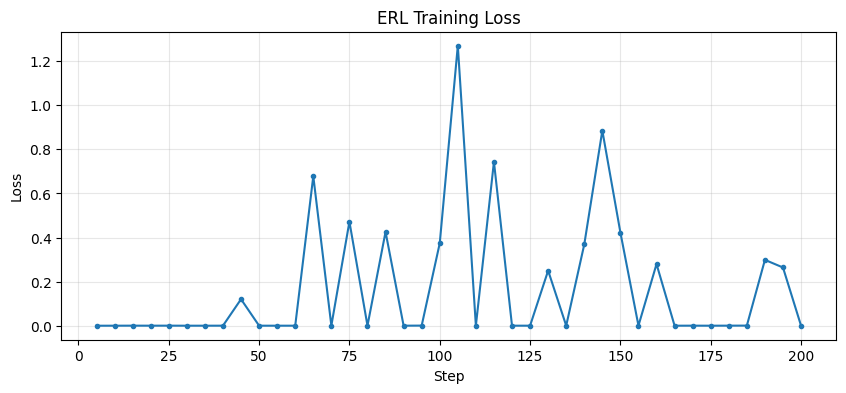


Final memory size: 18
Total steps: 200


In [14]:
import matplotlib.pyplot as plt

config_long = ERLConfig(
    output_dir="/content/erl-test-long",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    num_generations=4,
    max_completion_length=48,
    learning_rate=5e-6,
    reward_threshold=0.8,
    memory_size=50,
    memory_top_k=3,
    enable_memory=True,
    enable_internalization=True,
    erl_rl_coef=1.0,
    erl_debug=False,                        # ← off for longer run (less noise)
    report_to="none",
    logging_steps=5,
    save_strategy="no",
    bf16=torch.cuda.is_available(),
)

trainer_long = ERLTrainer(
    model=MODEL,
    reward_funcs=math_reward,
    args=config_long,
    train_dataset=dataset,
)

print("=" * 60)
print("SCENARIO 6: Longer training — 2 epochs, tracking loss")
print("=" * 60)
result = trainer_long.train()

# Plot training loss
log_history = trainer_long.state.log_history
steps = [entry["step"] for entry in log_history if "loss" in entry]
losses = [entry["loss"] for entry in log_history if "loss" in entry]

if steps:
    plt.figure(figsize=(10, 4))
    plt.plot(steps, losses, marker="o", markersize=3)
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("ERL Training Loss")
    plt.grid(True, alpha=0.3)
    plt.show()

print(f"\nFinal memory size: {len(trainer_long.memory) if trainer_long.memory else 0}")
print(f"Total steps: {trainer_long.state.global_step}")

del trainer_long
torch.cuda.empty_cache()

In [16]:
call_count = 0

def counting_reward(prompts, completions, answer, **kwargs):
    """Counts how many times the reward function is actually called."""
    global call_count
    call_count += 1
    results = []
    for completion, expected in zip(completions, answer):
        text = completion if isinstance(completion, str) else completion[0].get("content", "")
        results.append((1.0 if expected in text else 0.0, f"expected {expected}"))
    return results

config_count = ERLConfig(
    output_dir="/content/erl-test-count",
    num_train_epochs=1,
    max_steps=3,
    per_device_train_batch_size=4,
    num_generations=2,
    max_completion_length=32,
    learning_rate=1e-5,
    reward_threshold=0.9,
    erl_debug=False,
    report_to="none",
    logging_steps=1,
    save_strategy="no",
    bf16=torch.cuda.is_available(),
)

call_count = 0
trainer_count = ERLTrainer(
    model=MODEL,
    reward_funcs=counting_reward,
    args=config_count,
    train_dataset=dataset,
)
trainer_count.train()

# Each step: 1 call for y1 (by parent, cached) + 1 call for y2 (by ERL) = 2 per step
# Without caching it would be 3 (parent + ERL y1 re-call + ERL y2)
print(f"\nReward function calls over {config_count.max_steps} steps: {call_count}")
print(f"Expected: ~{config_count.max_steps * 2} (1 for y1 via parent + 1 for y2)")
print(f"Without caching it would be: ~{config_count.max_steps * 3}")

del trainer_count
torch.cuda.empty_cache()

close.started
close.complete
connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d945216630>
start_tls.started ssl_context=<ssl.SSLContext object at 0x79d983d9df50> server_hostname='huggingface.co' timeout=10
start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d945215490>
send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'256'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:28:23 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'278'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:28:25 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/generation_config.json?%2FQwen%2FQwen2.5-0.5B-Instruct%2Fresolve%2Fmain%2Fgeneration_config.json=&etag=%22dfc11073787daf1b0f9c0f1499487ab5f4c93738%22'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-69b689c9-6f46ee9a1c5a93d374d338fe;329024db-f4c5-49b1-b9b0-8ad2422479d4'), (b'RateLimit', b'"resolvers";r=2992;t=176'), (b'RateLimit-Policy', b'"fixed window";"resolvers";q=3000;w=300'), (b'cross-o

Step,Training Loss
1,0.000000
2,0.000000
3,0.000000



Reward function calls over 3 steps: 4
Expected: ~6 (1 for y1 via parent + 1 for y2)
Without caching it would be: ~9


In [17]:
# Reload a fresh trainer for manual probing
trainer_probe = ERLTrainer(
    model=MODEL,
    reward_funcs=math_reward,
    args=ERLConfig(
        output_dir="/content/erl-probe",
        max_steps=1,
        per_device_train_batch_size=4,
        num_generations=2,
        max_completion_length=32,
        reward_threshold=0.9,
        erl_debug=True,
        report_to="none",
        save_strategy="no",
        bf16=torch.cuda.is_available(),
    ),
    train_dataset=dataset,
)

print("=== Reflection prompt construction ===")
prompt = trainer_probe._build_reflection_prompt(
    prompt="What is 25 + 17? Answer with just the number.",
    attempt="The answer is 43.",
    feedback="Wrong. Expected 42, got: The answer is 43.",
    reward=0.0,
    memory_entries=["Previously: double-check arithmetic by computing step by step."],
)
print(prompt)

print("\n=== Retry prompt construction ===")
retry = trainer_probe._build_retry_prompt(
    prompt="What is 25 + 17? Answer with just the number.",
    reflection="I made an arithmetic error. 25 + 17 = 42, not 43. I need to be more careful.",
)
print(retry)

print("\n=== Advantage computation ===")
rewards = torch.tensor([0.0, 1.0, 0.0, 0.5, 0.0, 1.0])
adv = ERLTrainer._erl_compute_r2_advantages(rewards)
for r, a in zip(rewards.tolist(), adv.tolist()):
    print(f"  reward={r:.1f} → advantage={a:+.3f}")

del trainer_probe
torch.cuda.empty_cache()

close.started
close.complete
connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d9555436b0>
start_tls.started ssl_context=<ssl.SSLContext object at 0x79d983d9df50> server_hostname='huggingface.co' timeout=10
start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x79d955543b00>
send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'256'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:29:34 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

send_request_headers.started request=<Request [b'HEAD']>
send_request_headers.complete
send_request_body.started request=<Request [b'HEAD']>
send_request_body.complete
receive_response_headers.started request=<Request [b'HEAD']>
receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'278'), (b'Connection', b'keep-alive'), (b'Date', b'Sun, 15 Mar 2026 10:29:35 GMT'), (b'Location', b'/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/generation_config.json?%2FQwen%2FQwen2.5-0.5B-Instruct%2Fresolve%2Fmain%2Fgeneration_config.json=&etag=%22dfc11073787daf1b0f9c0f1499487ab5f4c93738%22'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-69b68a0f-2489a0192d8bcbc31b3dfaf8;7dbc3795-c053-4506-9bdd-41f5976f38f4'), (b'RateLimit', b'"resolvers";r=2987;t=106'), (b'RateLimit-Policy', b'"fixed window";"resolvers";q=3000;w=300'), (b'cross-o

=== Reflection prompt construction ===
You are analyzing a failed attempt at a task to help improve the next attempt.

## Original Task
What is 25 + 17? Answer with just the number.

## Your Previous Attempt
The answer is 43.

## Feedback Received
Wrong. Expected 42, got: The answer is 43.

## Reward Score
0.0

## Relevant Past Reflections
Previously: double-check arithmetic by computing step by step.

Based on the above, write a concise reflection:

1. What specifically went wrong in the previous attempt?
2. What concrete changes should be made in the next attempt?
3. What strategy should be followed?

Be specific and actionable. Focus on what to change, not what was wrong in general.

=== Retry prompt construction ===
You are making a second attempt at a task, guided by a reflection on your previous attempt.

## Original Task
What is 25 + 17? Answer with just the number.

## Reflection and Improvement Plan
I made an arithmetic error. 25 + 17 = 42, not 43. I need to be more careful.

